In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

# B-tree fragments

In [2]:
def load_dfs(fs):
    dfs = {}
    for fname in fs:
        freq = fname.split("_")[1]
        dfs[freq] = pd.read_csv(fname)

    return dfs

def plot_hist(dfs):
    fig, ax = plt.subplots(1,3, figsize=(20,4))

    amon = dfs["Amon"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[0], alpha=.5)
    day = dfs["day"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[1], alpha=.5)
    hr3 = dfs["3hr"].pivot(columns="dataset", values="offset").plot.hist(stacked=True, legend=False, ax=ax[2], alpha=.5)

    _ = ax[0].set_xlabel("Byte offsets of B-tree nodes (monthly).")
    _ = ax[1].set_xlabel("Byte offsets of B-tree nodes (daily).")
    _ = ax[2].set_xlabel("Byte offsets of B-tree nodes (3-hourly).")
    
    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor=(0.5, -0.1))
    
    ax[1].set_ylabel(None)
    ax[2].set_ylabel(None)

    fig.tight_layout()

    return fig, ax

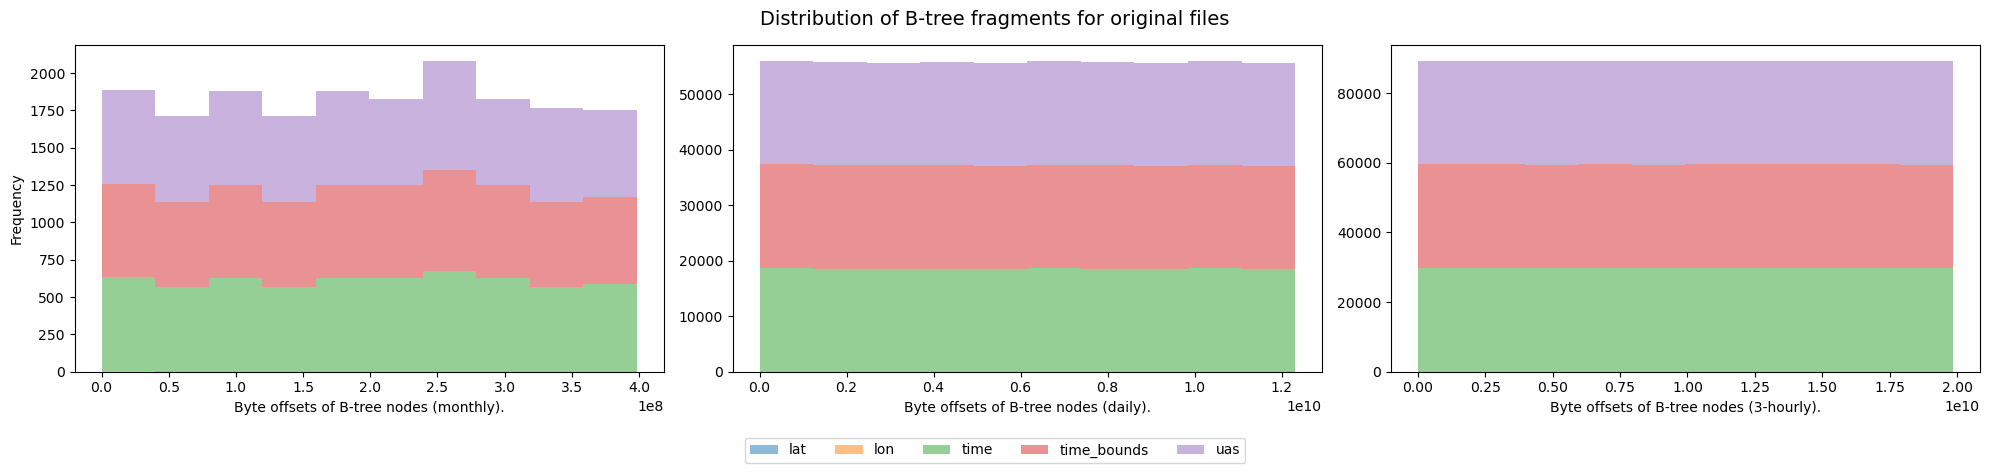

In [3]:
dfs = load_dfs([
    "csv/uas_3hr_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_187001010300-197001010000.csv.zip",
    "csv/uas_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912.csv.zip",
    "csv/uas_day_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_18500101-23491231.csv.zip",
])

fig, ax = plot_hist(dfs)
fig.suptitle("Distribution of B-tree fragments for original files", y=1.05, fontsize=14)

plt.savefig("btrees-norepack.pdf", bbox_inches="tight")

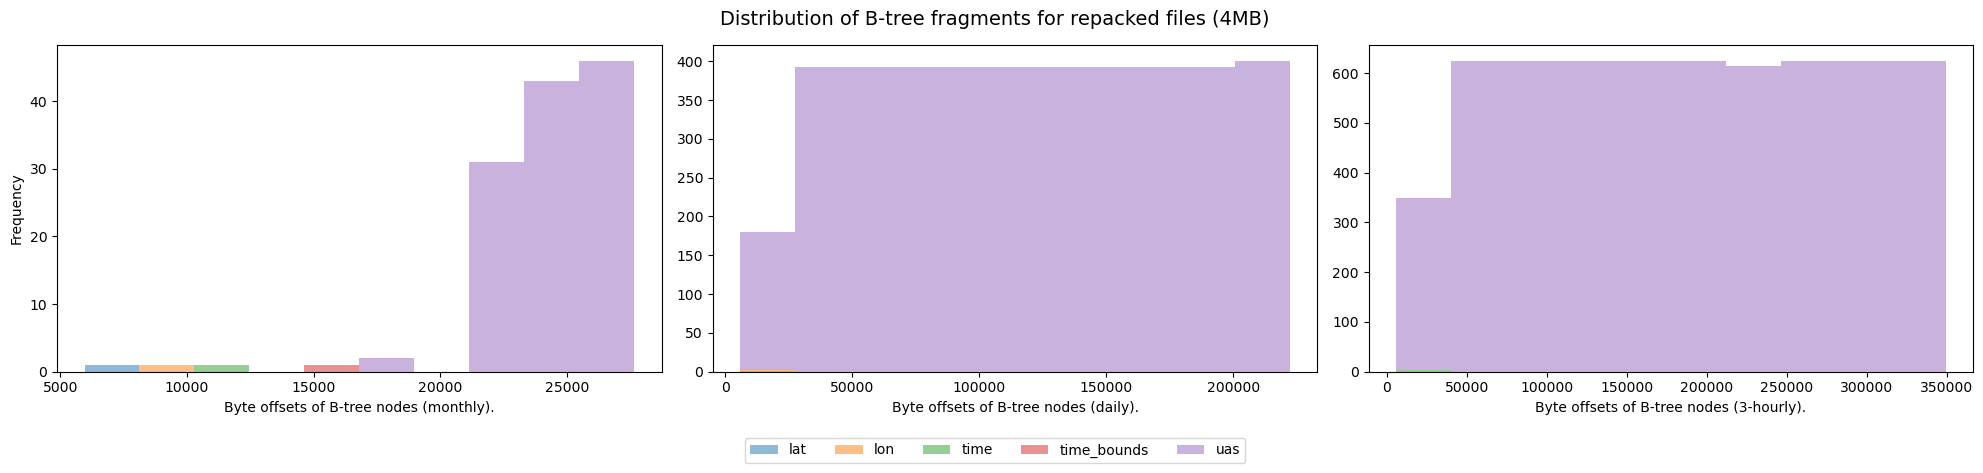

In [4]:
dfs = load_dfs([
    "csv/uas_3hr_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_187001010300-197001010000_cmip7repack4mb.csv.zip",
    "csv/uas_Amon_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_185001-234912_cmip7repack4mb.csv.zip",
    "csv/uas_day_IPSL-CM6A-LR_piControl_r1i1p1f1_gr_18500101-23491231_cmip7repack4mb.csv.zip",
])

fig, ax = plot_hist(dfs)
fig.suptitle("Distribution of B-tree fragments for repacked files (4MB)", y=1.05, fontsize=14)

plt.savefig("btrees-4mbrepack.pdf", bbox_inches="tight")

# Performance

Load the results.

In [5]:
df = pd.read_csv("results.csv")

df["tp"] = df["bytes_recv"] / df["time"] / 2**20

df.loc[df["workers"]==101, "package"] = "kerchunk (original async)"
df.loc[(df["workers"]==100) & (df["package"]=="kerchunk"), "package"] = "kerchunk (repacked async)"
df.loc[(df["workers"]==100) & (df["package"]=="pyfive"), "package"] = "pyfive (repacked async)"
df.loc[(df["workers"]==1) & (df["package"]=="pyfive"), "package"] = "pyfive (repacked serial)"

df = df[~(df["name"]=="locate")]

Plot results.

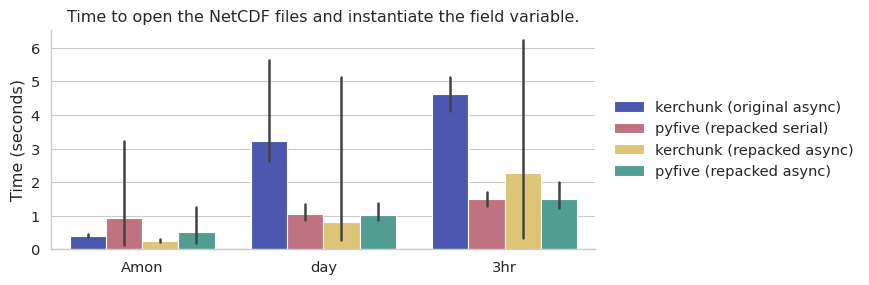

In [6]:
seaborn.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

palette = {
    "kerchunk (original async)": "#3B4CC0",
    "pyfive (repacked serial)": "#CC6677",
    "kerchunk (repacked async)": "#EECC66",
    "pyfive (repacked async)": "#44AA99",
}

fig, ax = plt.subplots(figsize=(10, 3))

seaborn.barplot(
    data=df[df["name"] == "open"],
    x="frequency",
    y="time",
    hue="package",
    hue_order=[
        "kerchunk (original async)",
        "pyfive (repacked serial)",
        "kerchunk (repacked async)",
        "pyfive (repacked async)",
    ],
    order=["Amon", "day", "3hr"],
    palette=palette,
    errorbar=("pi", 100),
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Time (seconds)")
ax.set_title("Time to open the NetCDF files and instantiate the field variable.")

seaborn.despine(ax=ax)

ax.legend(
    loc="center right",
    bbox_to_anchor=(1.5, .5),
    frameon=False,
)

fig.tight_layout()
fig.savefig("open.pdf", bbox_inches="tight")
plt.show()

In [7]:
tp = df[df["name"]=="load"][["package", "frequency", "tp"]].groupby(["package", "frequency"]).mean().reset_index()
tp.pivot(index="package", columns="frequency", values="tp").loc[["kerchunk (original async)", "pyfive (repacked serial)", "kerchunk (repacked async)", "pyfive (repacked async)"], ["Amon", "day", "3hr"]]

frequency,Amon,day,3hr
package,,,
kerchunk (original async),11.970428,23.048000,25.273166
pyfive (repacked serial),16.126002,4.829257,3.511848
kerchunk (repacked async),67.706912,41.554107,38.365358
pyfive (repacked async),43.676933,65.059523,63.570538


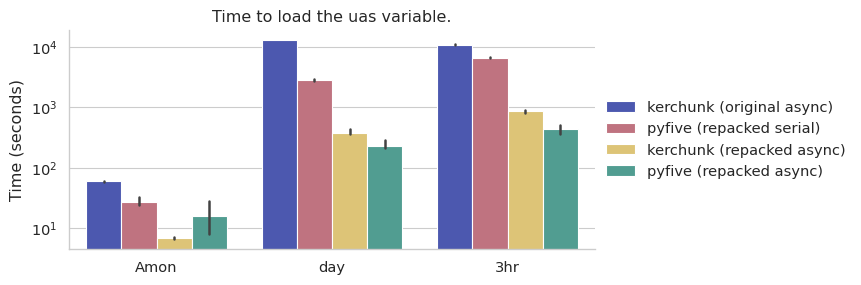

In [8]:
seaborn.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.2
)

palette = {
    "kerchunk (original async)": "#3B4CC0",
    "pyfive (repacked serial)": "#CC6677",
    "kerchunk (repacked async)": "#EECC66",
    "pyfive (repacked async)": "#44AA99",
}

fig, ax = plt.subplots(figsize=(10, 3))

seaborn.barplot(
    data=df[df["name"] == "load"],
    x="frequency",
    y="time",
    hue="package",
    hue_order=[
        "kerchunk (original async)",
        "pyfive (repacked serial)",
        "kerchunk (repacked async)",
        "pyfive (repacked async)",
    ],
    order=["Amon", "day", "3hr"],
    palette=palette,
    errorbar=("pi", 100),
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Time (seconds)")
ax.set_title("Time to load the uas variable.")
ax.set(yscale="log")

seaborn.despine(ax=ax)

ax.legend(
    loc="center right",
    bbox_to_anchor=(1.5, .5),
    frameon=False,
)

fig.tight_layout()
fig.savefig("load.pdf", bbox_inches="tight")
plt.show()